## HydroSOS - Persistence and Hydrological Analogues method

In this notebook, we explore the Persistance and Hydrological Analogue method
Firts, we import the python libraries

In [1]:
%reset -f

In [2]:
# Importing the libraries
import pandas as pd
import seaborn as sns
import numpy as np
import calendar
import datetime
import matplotlib.pyplot as plt
plt.style.use('classic')
from scipy.stats.mstats import mquantiles
import os
%matplotlib inline

from IPython.display import HTML

sns.set()

In [3]:
alphap = 0.4
betap = 0.4

def quantile_position(x, p, alphap=0.4, betap=0.4):
    # For Weibull use alphap = 0.0 and betap = 0.0. For Cunnane use alphap = 0.4 and betap = 0.4
    return mquantiles(x.dropna(), p, alphap=alphap, betap=betap)[0]

We create function for percentile definition

In [4]:
# Quantile Function Definitions
def q1(x):
    return quantile_position(x, 0.28,alphap=0.4, betap=0.4)
def q2(x):   
    return quantile_position(x, 0.50,alphap=0.4, betap=0.4)
def q3(x):   
    return quantile_position(x, 0.72,alphap=0.4, betap=0.4)
def q5(x):   
    return quantile_position(x, 0.05,alphap=0.4, betap=0.4)
def q95(x):  
    return quantile_position(x, 0.95,alphap=0.4, betap=0.4)
def q87(x):  
    return quantile_position(x, 0.87,alphap=0.4, betap=0.4)
def q13(x):  
    return quantile_position(x, 0.13,alphap=0.4, betap=0.4)
def q10(x):  
    return quantile_position(x, 0.10,alphap=0.4, betap=0.4)
def q25(x):  
    return quantile_position(x, 0.25,alphap=0.4, betap=0.4)
def q75(x):  
    return quantile_position(x, 0.75,alphap=0.4, betap=0.4)
def q90(x):  
    return quantile_position(x, 0.90,alphap=0.4, betap=0.4)
def q50(x):  
    return quantile_position(x, 0.50,alphap=0.4, betap=0.4)
def q33(x):  
    return quantile_position(x, 0.33,alphap=0.4, betap=0.4)
def q66(x):  
    return quantile_position(x, 0.66,alphap=0.4, betap=0.4)

We import the monthly discharge data from Fray Marcos station

In [5]:
station_name = '101'
input_folder = os.path.join('../stations/data', f'{station_name}.csv')
DISCHARGE_DAILY = pd.read_csv(input_folder,parse_dates=['Fecha'],index_col="Fecha",dayfirst=True,na_values="NA")

In [6]:
# Identify the missing data
DISCHARGE_DAILY_date_missing = pd.date_range(start = DISCHARGE_DAILY.index[0].strftime('%Y-%m-%d'), end = DISCHARGE_DAILY.index[-1].strftime('%Y-%m-%d'),freq='D')
# Re-index the dataframe based on the missind date variable
DISCHARGE_DAILY = DISCHARGE_DAILY.reindex(DISCHARGE_DAILY_date_missing,fill_value=None)
# Set index Fecha
DISCHARGE_DAILY.index.name = 'Date' 
# Change columns names
DISCHARGE_DAILY.columns = ['Discharge']
# Print the last 6 values
HTML(DISCHARGE_DAILY.tail(6).to_html())

,Discharge
Date,
2026-08-26,167.612
2026-08-27,120.881
2026-08-28,148.867
2026-08-29,251.454
2026-08-30,416.887
2026-08-31,341.834


### Plot the results

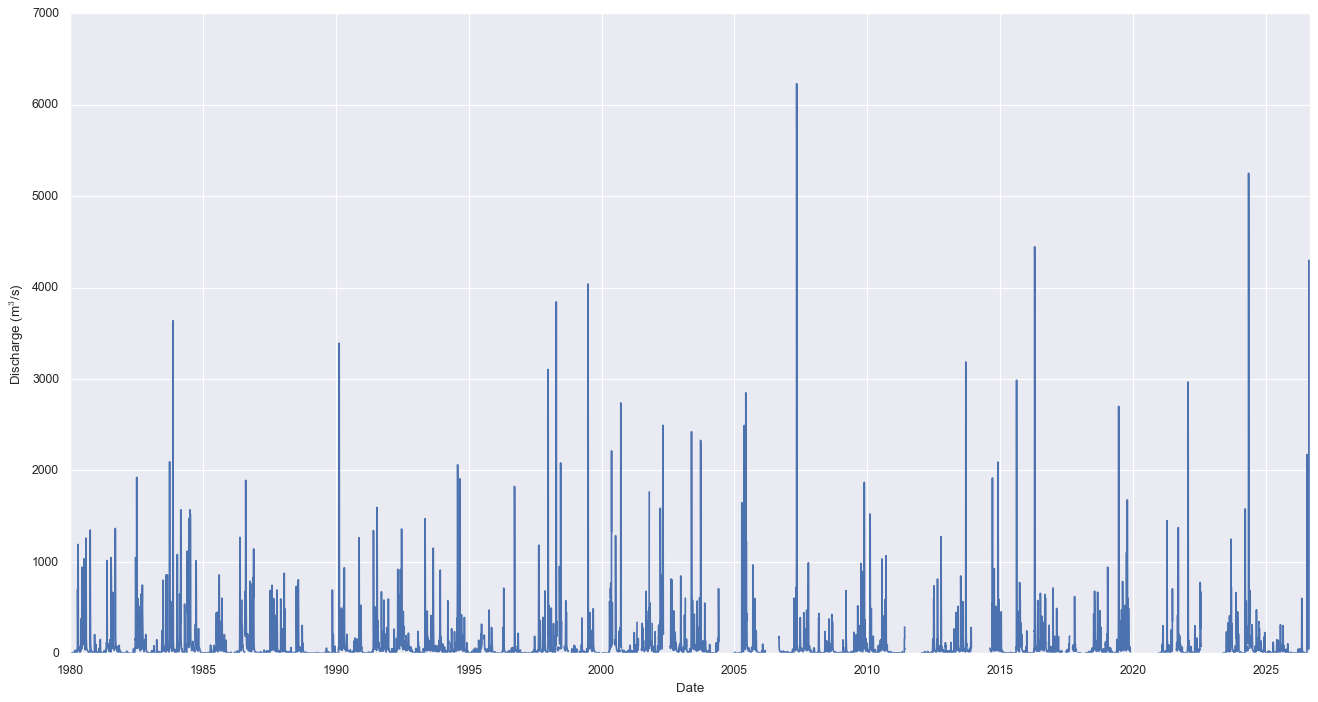

In [7]:
ax1 = DISCHARGE_DAILY['Discharge'].plot(figsize=(20, 10));
ax1.set_xlabel('Date');
ax1.set_ylabel('Discharge (m$^3$/s)');

## Calculate monthly mean from daily data

First, we identify the months which contains lower that 5 null value observation.

In [8]:
# group the Dataframe in a monthly time scale
GROUPER_DISCHARGE_MONTHLY = DISCHARGE_DAILY.groupby(pd.Grouper(freq='1MS'))
NUMBER_MISSING = GROUPER_DISCHARGE_MONTHLY.apply(lambda x: pd.isnull(x).sum()).unstack(1)
# sum the number of null values and assing a "true" if the number of null values are lower that a number for a given month
BOOL_MISSING = GROUPER_DISCHARGE_MONTHLY.apply(lambda x: pd.isnull(x).sum()).unstack(1) < 5
BOOL_MISSING = BOOL_MISSING.to_frame() # convert to DataFrame
BOOL_MISSING.columns = ['missing'] # change the column name to "missing"

NUMBER_MISSING = NUMBER_MISSING.to_frame()
NUMBER_MISSING.columns = ['number_missing'] # change the column name to "missing"

After this, we calculate the monthly mean flow only if the null values in that month are below 5 values

In [9]:
DISCHARGE_MONTHLY = DISCHARGE_DAILY.resample('M').apply(lambda x: x.mean() if x.isnull().sum() < 5 else np.nan)
DISCHARGE_MONTHLY['Year'] = DISCHARGE_MONTHLY.index.year
DISCHARGE_MONTHLY['Month'] = DISCHARGE_MONTHLY.index.month
DISCHARGE_MONTHLY['water_year'] = DISCHARGE_MONTHLY.index.year.where(DISCHARGE_MONTHLY.index.month < 4, DISCHARGE_MONTHLY.index.year + 1)

## create column for day, month, year in the daily discharge ()
DISCHARGE_DAILY['Year'] = DISCHARGE_DAILY.index.year
DISCHARGE_DAILY['Month'] = DISCHARGE_DAILY.index.month
DISCHARGE_DAILY['Day'] = DISCHARGE_DAILY.index.day
DISCHARGE_DAILY['monthday'] = DISCHARGE_DAILY.index.day_of_year
DISCHARGE_DAILY['water_year'] = DISCHARGE_DAILY.index.year.where(DISCHARGE_DAILY.index.month < 4, DISCHARGE_DAILY.index.year + 1)
## 
HTML(DISCHARGE_MONTHLY.head(18).to_html(index=False))
# DISCHARGE_MONTHLY.to_clipboard()

Discharge,Year,Month,water_year
4.194484,1980,1,1980
4.525586,1980,2,1980
12.688516,1980,3,1980
195.164000,1980,4,1981
37.597129,1980,5,1981
310.117033,1980,6,1981
200.092871,1980,7,1981
160.012548,1980,8,1981
12.893267,1980,9,1981
175.533161,1980,10,1981


## Select by Climatology range

First, we transform the discharge to a logaritmic scale and we insert it in the dataframe

In [10]:
DISCHARGE_MONTHLY['Q_to_log'] = np.log(DISCHARGE_MONTHLY['Discharge'])

In [11]:
HTML(DISCHARGE_MONTHLY.tail(6).to_html(index=False))

Discharge,Year,Month,water_year,Q_to_log
NaN,2026,3,2026,NaN
NaN,2026,4,2027,NaN
79.363032,2026,5,2027,4.374033
6.260233,2026,6,2027,1.834217
200.582226,2026,7,2027,5.301224
628.475903,2026,8,2027,6.443298


we plot a Histogram that show the Discharge distribution after the log-transformation

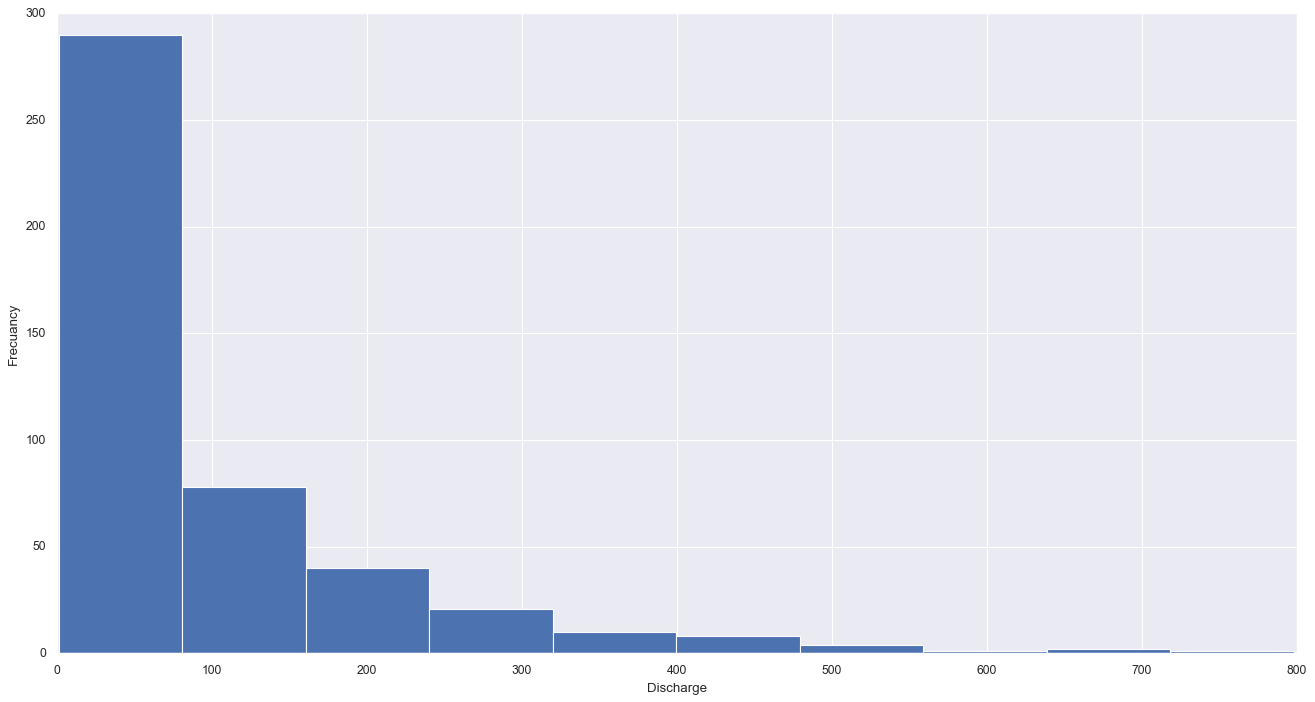

In [12]:
ax2 = DISCHARGE_MONTHLY['Discharge'].hist(figsize=(20, 10));
# ax2.set_xlim(-3.0,3.0)
ax2.set_xlabel('Discharge');
ax2.set_ylabel('Frecuancy');

In this part we select the reference period for analysis. In this case we use the 1991-2020 period

In [13]:
# DISCHARGE_MONTHLY_SELECTED = DISCHARGE_MONTHLY
DISCHARGE_MONTHLY_SELECTED = DISCHARGE_MONTHLY.loc['2004-01-01':'2021-12-31'] # Recent INUMET reference period
HTML(DISCHARGE_MONTHLY_SELECTED.tail(6).to_html(index=False))

Discharge,Year,Month,water_year,Q_to_log
NaN,2021,7,2022,NaN
NaN,2021,8,2022,NaN
274.306600,2021,9,2022,5.614246
49.399000,2021,10,2022,3.899930
NaN,2021,11,2022,NaN
4.722179,2021,12,2022,1.552270


Extract the years from the monthly discharge dataframe

In [14]:
YEAR_SELECTED = np.unique(DISCHARGE_MONTHLY_SELECTED['Year'])
display(YEAR_SELECTED)

array([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021], dtype=int64)

Plot the monthly log Discharge in a BoxPlot Graph

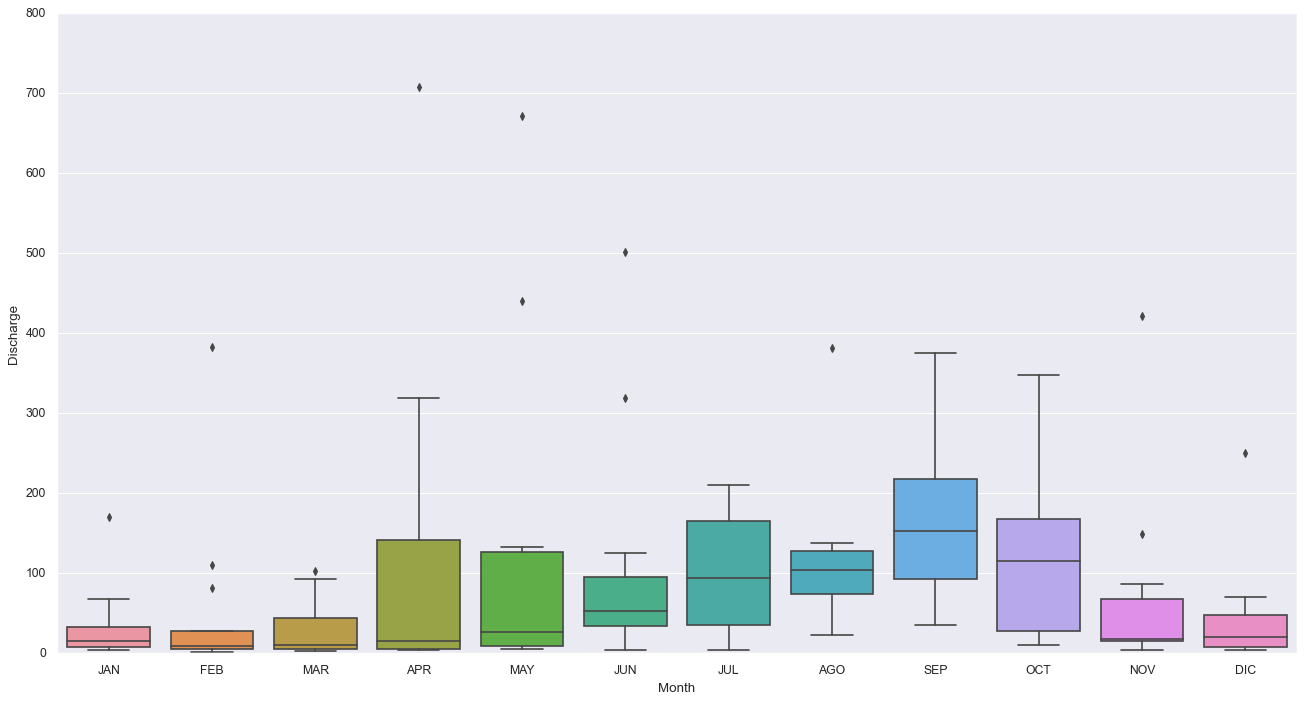

In [15]:
ax3 = plt.figure(figsize=(20, 10))
ax3 = sns.boxplot(data = DISCHARGE_MONTHLY_SELECTED, x='Month', y='Discharge');
ax3.set_xticklabels(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AGO','SEP','OCT','NOV','DIC']);

## Calculate Monthly statistics

In this part we calculate monthly statistcs for the QLog Variable. The statistis include: mean, min, max,25 pct, 50 pct, 75 pct

In [16]:
DISCHARGE_MONTHLY_STATS = DISCHARGE_MONTHLY_SELECTED.Discharge.groupby(DISCHARGE_MONTHLY_SELECTED.index.month).agg([np.min, q10, q33, q25, np.mean, q50, q66, q75, q90, np.max, np.std])
# Display results
HTML(DISCHARGE_MONTHLY_STATS.to_html())

,amin,q10,q33,q25,mean,q50,q66,q75,q90,amax,std
Date,,,,,,,,,,,
1,3.910742,4.130802,9.635780,7.483400,33.093739,15.272968,25.141559,36.002363,107.366141,170.737581,47.202780
2,2.244607,3.866691,6.059391,5.963314,49.502135,8.926196,23.873959,30.881416,159.639266,382.575214,101.146235
3,3.304645,3.609902,7.192898,4.897697,29.071536,10.824710,36.764885,44.823435,95.744849,103.466129,34.355395
4,3.903933,4.311091,7.653820,5.270567,111.489563,14.869022,52.703584,170.538452,388.905918,708.212633,198.151109
5,4.845290,5.153497,10.520520,8.398487,118.021256,26.539000,59.103719,128.505590,504.781119,671.701065,204.552491
6,4.331633,8.667500,40.875076,30.846463,111.450968,52.517867,80.698132,106.846172,388.847552,501.571033,148.725680
7,4.491935,16.491675,46.087696,34.465021,102.132312,94.038613,155.782139,169.033221,192.799682,210.645742,72.344020
8,23.452355,41.740637,81.820754,69.780826,119.116249,104.630161,119.516906,130.095826,255.029000,381.798290,93.540339
9,35.439867,40.528683,100.889297,90.265762,164.753389,153.264650,199.151594,225.215603,293.411577,375.215433,98.574496


We plot the median, 28th and 72th percentile

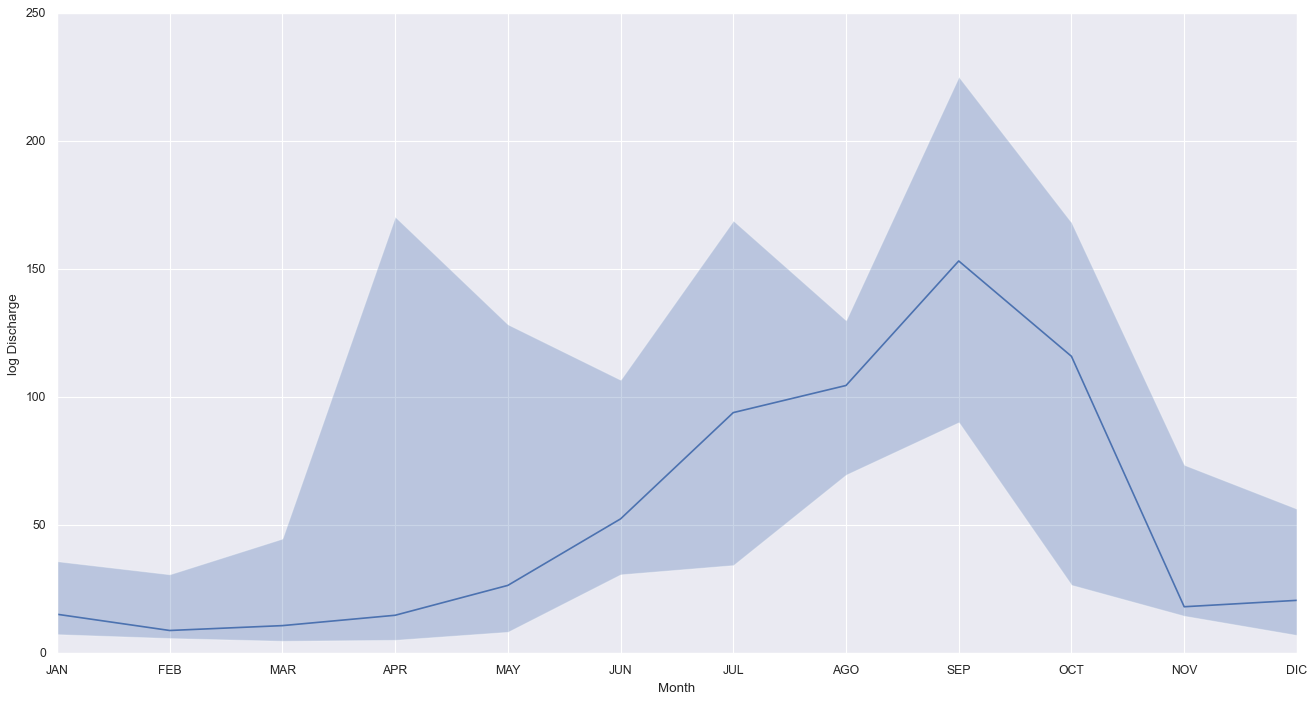

In [17]:
plt.figure(figsize=(20, 10))
plt.plot(DISCHARGE_MONTHLY_STATS.index,DISCHARGE_MONTHLY_STATS['q50'], '-')
# plt.fill_between(monthly_sst.index, monthly_sst['q2'] + monthly_sst['std'], monthly_sst['q2'] - monthly_sst['std'],alpha=0.3)
plt.fill_between(DISCHARGE_MONTHLY_STATS.index, DISCHARGE_MONTHLY_STATS['q25'], DISCHARGE_MONTHLY_STATS['q75'],alpha=0.3)
plt.xlim(1,12)
plt.xticks(DISCHARGE_MONTHLY_STATS.index,labels=['JAN','FEB','MAR','APR','MAY','JUN','JUL','AGO','SEP','OCT','NOV','DIC']);
plt.xlabel('Month');
plt.ylabel('log Discharge');

## Calculate Daily statistics

We reproduce the same procedure for the Daily dataframe

In [18]:
DISCHARGE_DAILY_STATS = DISCHARGE_DAILY.Discharge.groupby(DISCHARGE_DAILY.monthday).agg([np.min, q10, q25, np.mean, q50, q75, q90, np.max, np.std])
HTML(DISCHARGE_DAILY_STATS.head(12).to_html())

,amin,q10,q25,mean,q50,q75,q90,amax,std
monthday,,,,,,,,,
1,1.585,2.67152,4.33810,30.731122,10.1730,28.08030,84.65388,306.221,58.295569
2,1.513,2.63264,4.25870,34.437683,9.7590,26.52550,81.93048,270.630,66.434527
3,1.458,2.59664,4.28950,29.564951,9.0400,31.63260,68.74140,218.920,50.469584
4,1.415,2.58752,4.27690,24.251341,8.4010,32.34570,58.26980,213.153,37.611009
5,1.413,2.52694,3.98550,21.245550,9.5450,28.38335,48.71508,184.842,32.470752
6,1.451,2.19484,3.86200,21.485732,9.0680,25.23990,48.02640,182.648,34.234730
7,1.417,2.11170,3.83090,26.508167,8.2370,23.75770,53.36754,304.989,58.163642
8,1.417,2.04732,3.71675,30.328714,7.8230,21.79935,68.37262,524.349,83.106653
9,1.415,1.98346,3.58960,31.556310,8.3985,20.67165,58.74040,454.897,78.436071


In [19]:
# From DISCHARGE_DAILY extract the year 2026
year_select = [2026, 1982, 1991, 1997, 2015, 2023]
# year_select = [2026, 1982, 1997, 2015, 2023]
# year_select = [2026,2013,2003]

# Filtrar por la columna 'Year' (año calendario)
DISCHARGE_YEAR_SELECTED = DISCHARGE_DAILY[DISCHARGE_DAILY["Year"].isin(year_select)]
DISCHARGE_YEAR_SELECTED

,Discharge,Year,Month,Day,monthday,water_year
Date,,,,,,
1982-01-01,4.363,1982,1,1,1,1982
1982-01-02,4.209,1982,1,2,2,1982
1982-01-03,4.209,1982,1,3,3,1982
1982-01-04,4.363,1982,1,4,4,1982
1982-01-05,4.057,1982,1,5,5,1982
...,...,...,...,...,...,...
2026-08-27,120.881,2026,8,27,239,2027
2026-08-28,148.867,2026,8,28,240,2027
2026-08-29,251.454,2026,8,29,241,2027


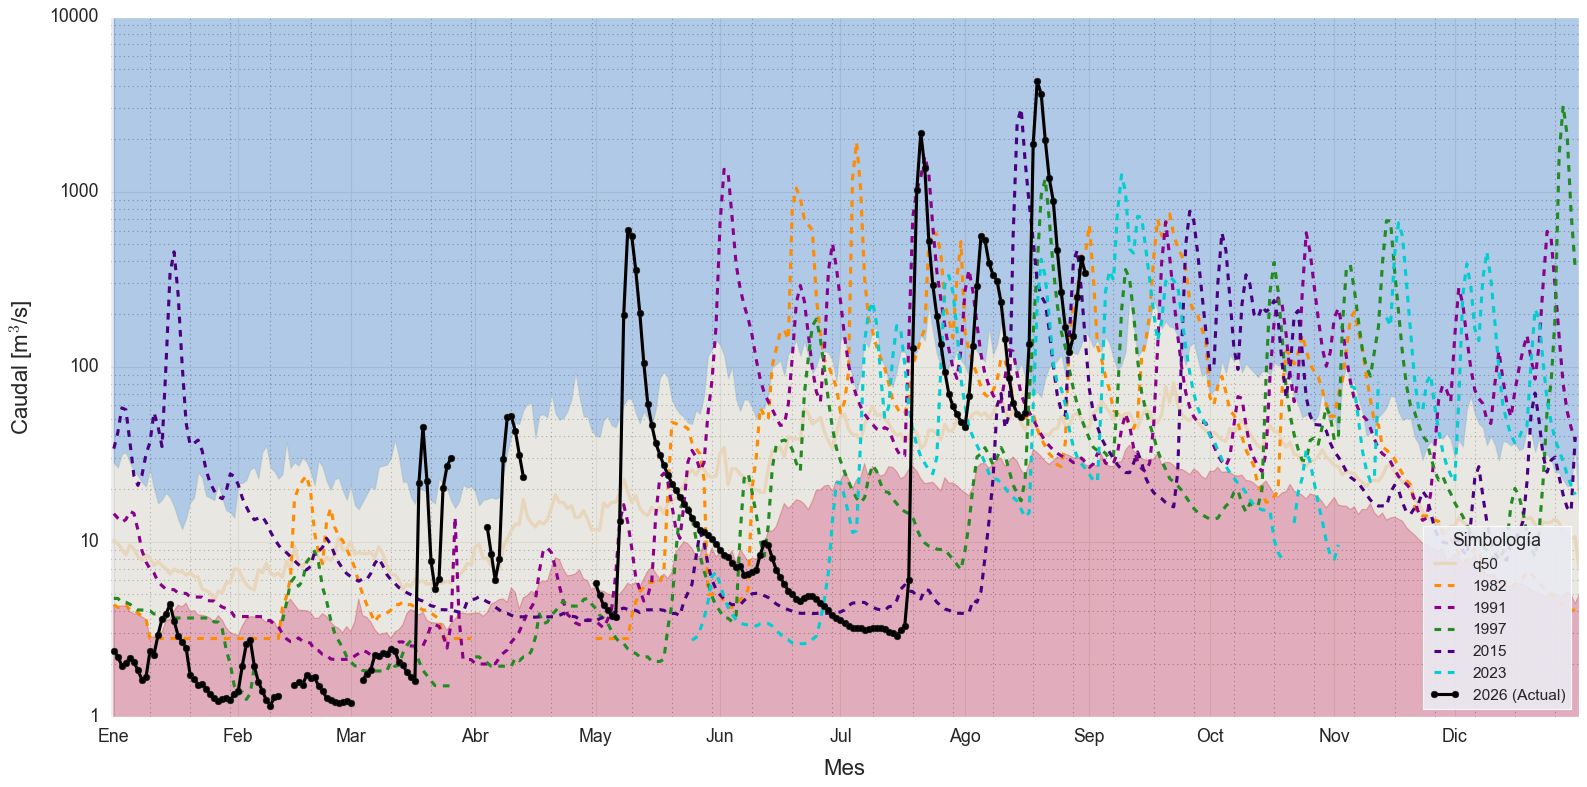

In [22]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


fig, ax = plt.subplots(figsize=(20, 10))

# Curva mediana y bandas de percentiles
ax.plot(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q50"],
    "-",
    color="#E7D6BC",
    linewidth=3.0,
    label="q50",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q75"],
    10000,
    alpha=0.3,
    color="#2C7DCD",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q25"],
    DISCHARGE_DAILY_STATS["q75"],
    alpha=0.3,
    color="#E7E2BC",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    0,
    DISCHARGE_DAILY_STATS["q25"],
    alpha=0.3,
    color="#CD233F",
)

# Paleta de alto contraste (evita azules/rojos/beige ya usados en las bandas) y variación de estilo de línea
CONTRAST_COLORS = [
    "#FF8C00",  # naranja oscuro
    "#8B008B",  # magenta oscuro
    "#228B22",  # verde bosque
    "#4B0082",  # índigo
    "#00CED1",  # turquesa oscuro
    "#8B4513",  # marrón silla
    "#FF1493",  # rosa profundo
    "#556B2F",  # oliva oscuro
    "#9400D3",  # violeta oscuro
    "#1B1B1B",  # casi negro
]
CONTRAST_LINESTYLES = ["--", "-.", ":", (0, (3, 1, 1, 1))]

years_list = sorted(y for y in DISCHARGE_YEAR_SELECTED["Year"].unique() if y != 2026)
year_color_map = {year: CONTRAST_COLORS[i % len(CONTRAST_COLORS)] for i, year in enumerate(years_list)}
year_linestyle_map = {
    year: CONTRAST_LINESTYLES[(i // len(CONTRAST_COLORS)) % len(CONTRAST_LINESTYLES)]
    for i, year in enumerate(years_list)
}

# Iterar y graficar cada año
for year, group in DISCHARGE_YEAR_SELECTED.groupby("Year"):
    if year == 2026:
        ax.plot(
            group["monthday"],
            group["Discharge"],
            label=f"{year} (Actual)",
            color="black",
            linewidth=2.8,
            alpha=1.0,
            zorder=5,
            # add marker with a circle and fill color white
            marker="o",
            markerfacecolor="black",
        )
    else:
        ax.plot(
            group["monthday"],
            group["Discharge"],
            label=str(year),
            color=year_color_map.get(year),
            linewidth=2.8,
            linestyle=year_linestyle_map.get(year),
            alpha=1.0,
            zorder=3,
        )

# -------------------------------------------------------------
# Configuración del eje X con nombres de Meses
# -------------------------------------------------------------
month_names = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}

month_ticks = (
    DISCHARGE_YEAR_SELECTED.drop_duplicates(subset=["Month"])
    .sort_values("monthday")[["Month", "monthday"]]
    .copy()
)
month_positions = month_ticks["monthday"].values
month_labels = [month_names[m] for m in month_ticks["Month"].values]

ax.set_xlim(1, 366)
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels, fontsize=16, fontweight="normal")
ax.set_xticks(np.arange(0, 366, 10.0), minor=True)

# -------------------------------------------------------------
# Escala Logarítmica y Formato Numérico Estándar (Eje Y)
# -------------------------------------------------------------
ax.set_yscale("log")

# Forzar formato decimal normal (0, 1, 10, 100, 1000...)
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

# Tamaños de texto
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16, which="both")

ax.set_xlabel("Mes", fontsize=20, labelpad=12, fontweight="normal")
# ax.set_ylabel("Nivel [m]", fontsize=20, labelpad=12, fontweight="normal")
ax.set_ylabel("Caudal [m$^3$/s]", fontsize=20, labelpad=12, fontweight="normal")

# Leyenda
ax.legend(
    title="Simbología",
    title_fontsize=16,
    fontsize=14,
    loc="lower right",
    framealpha=0.9,
)
# ax.title(f'Caudales registrados en ', {str(station_name)})
# Rejilla
ax.grid(True, which="major", linestyle="-", color="#d0d0d0", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", color="#1b1b1b", alpha=0.4)

plt.tight_layout()
plt.show()


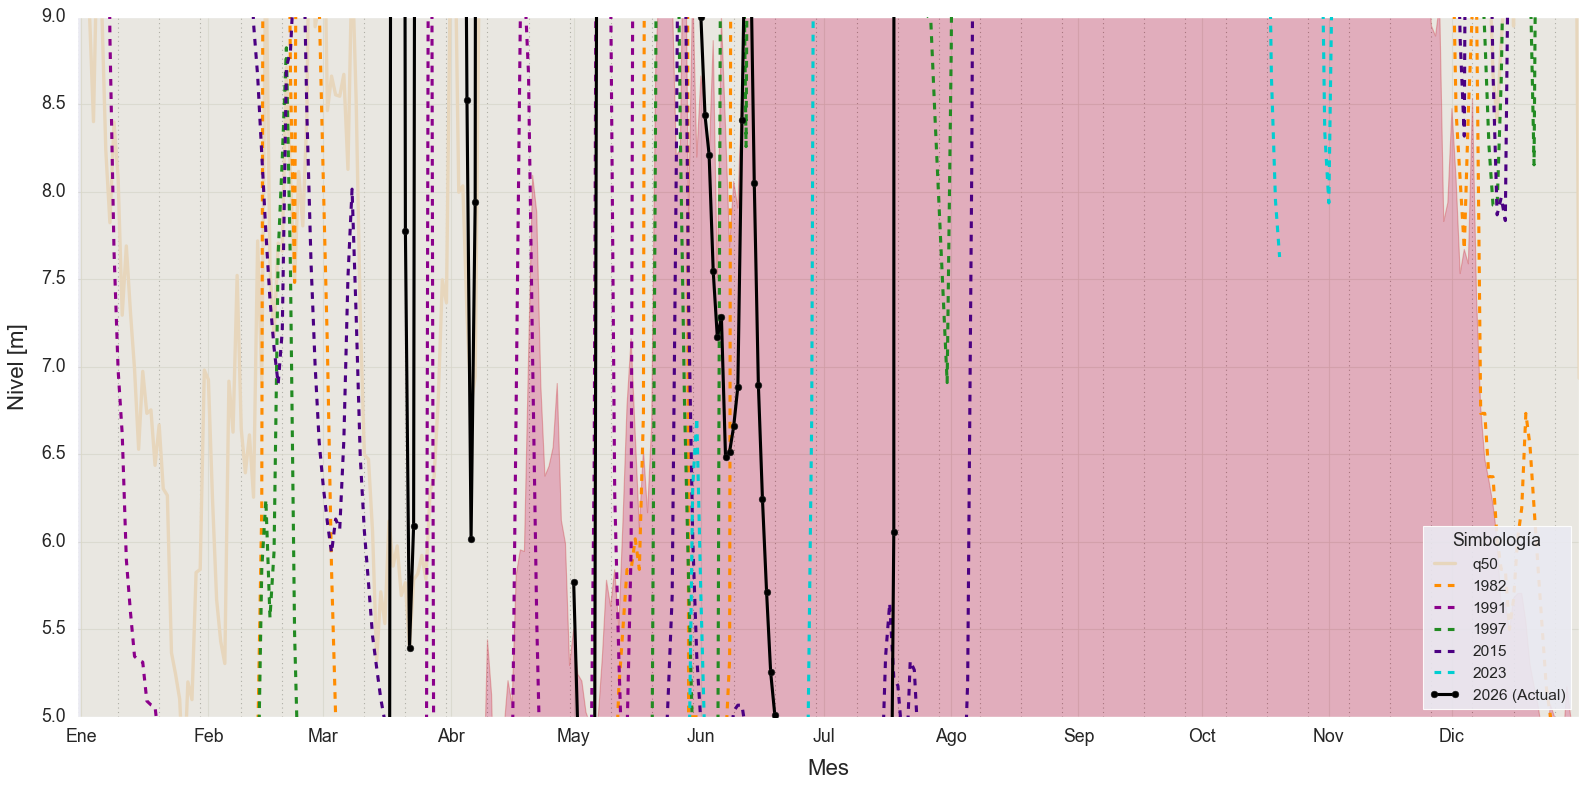

In [21]:
fig, ax = plt.subplots(figsize=(20, 10))

# Curva mediana y bandas de percentiles
ax.plot(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q50"],
    "-",
    color="#E7D6BC",
    linewidth=3.0,
    label="q50",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q75"],
    10,
    alpha=0.3,
    color="#2C7DCD",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q25"],
    DISCHARGE_DAILY_STATS["q75"],
    alpha=0.3,
    color="#E7E2BC",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    0,
    DISCHARGE_DAILY_STATS["q25"],
    alpha=0.3,
    color="#CD233F",
)

# Paleta de alto contraste (evita azules/rojos/beige ya usados en las bandas) y variación de estilo de línea
CONTRAST_COLORS = [
    "#FF8C00",  # naranja oscuro
    "#8B008B",  # magenta oscuro
    "#228B22",  # verde bosque
    "#4B0082",  # índigo
    "#00CED1",  # turquesa oscuro
    "#8B4513",  # marrón silla
    "#FF1493",  # rosa profundo
    "#556B2F",  # oliva oscuro
    "#9400D3",  # violeta oscuro
    "#1B1B1B",  # casi negro
]
CONTRAST_LINESTYLES = ["--", "-.", ":", (0, (3, 1, 1, 1))]

years_list = sorted(y for y in DISCHARGE_YEAR_SELECTED["Year"].unique() if y != 2026)
year_color_map = {year: CONTRAST_COLORS[i % len(CONTRAST_COLORS)] for i, year in enumerate(years_list)}
year_linestyle_map = {
    year: CONTRAST_LINESTYLES[(i // len(CONTRAST_COLORS)) % len(CONTRAST_LINESTYLES)]
    for i, year in enumerate(years_list)
}

# Iterar y graficar cada año
for year, group in DISCHARGE_YEAR_SELECTED.groupby("Year"):
    if year == 2026:
        ax.plot(
            group["monthday"],
            group["Discharge"],
            label=f"{year} (Actual)",
            color="black",
            linewidth=2.8,
            alpha=1.0,
            zorder=5,
            # add marker with a circle and fill color white
            marker="o",
            markerfacecolor="black",
        )
    else:
        ax.plot(
            group["monthday"],
            group["Discharge"],
            label=str(year),
            color=year_color_map.get(year),
            linewidth=2.8,
            linestyle=year_linestyle_map.get(year),
            alpha=1.0,
            zorder=3,
        )

# -------------------------------------------------------------
# Configuración del eje X con nombres de Meses
# -------------------------------------------------------------
month_names = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}

month_ticks = (
    DISCHARGE_YEAR_SELECTED.drop_duplicates(subset=["Month"])
    .sort_values("monthday")[["Month", "monthday"]]
    .copy()
)
month_positions = month_ticks["monthday"].values
month_labels = [month_names[m] for m in month_ticks["Month"].values]

ax.set_xlim(1, 366)
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels, fontsize=16, fontweight="normal")
ax.set_xticks(np.arange(0, 366, 10.0), minor=True)

# -------------------------------------------------------------
# Escala Logarítmica y Formato Numérico Estándar (Eje Y)
# -------------------------------------------------------------
# ax.set_yscale("log")

# Forzar formato decimal normal (0, 1, 10, 100, 1000...)
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

# Tamaños de texto
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16, which="both")

ax.set_ylim(5, 9)

ax.set_xlabel("Mes", fontsize=20, labelpad=12, fontweight="normal")
ax.set_ylabel("Nivel [m]", fontsize=20, labelpad=12, fontweight="normal")
# ax.set_ylabel("Caudal [m$^3$/s]", fontsize=20, labelpad=12, fontweight="normal")

# Leyenda
ax.legend(
    title="Simbología",
    title_fontsize=16,
    fontsize=14,
    loc="lower right",
    framealpha=0.9,
)
# ax.title(f'Caudales registrados en ', {str(station_name)})
# Rejilla
ax.grid(True, which="major", linestyle="-", color="#d0d0d0", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", color="#1b1b1b", alpha=0.4)

plt.tight_layout()
plt.show()
